##Task 3 – Customer Churn Prediction

Customer churn refers to the situation where customers stop using the services of a bank or company. Understanding why customers leave is important for improving customer retention strategies.

In this task, we analyze a bank customer dataset to identify patterns that influence customer churn. Exploratory data analysis and machine learning techniques are applied to predict whether a customer is likely to leave the bank.

The goal of this analysis is to help financial institutions understand customer behavior and take proactive actions to reduce churn.

##Import Libraries

In [1]:
# This step imports the required Python libraries for data analysis,
# visualization, and machine learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

##Load Dataset

In [2]:
# The dataset is loaded to analyze customer information and identify churn
# patterns.

df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


##Dataset Overview

This step helps understand the structure of the dataset including number of rows, columns, and data types.

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [6]:
# Columns that do not contribute to predicting churn are removed to simplify the
# model.

df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)

In [8]:
# The target variable 'Exited' indicates whether a customer has left the bank.

df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


##Visualize Churn by Gender

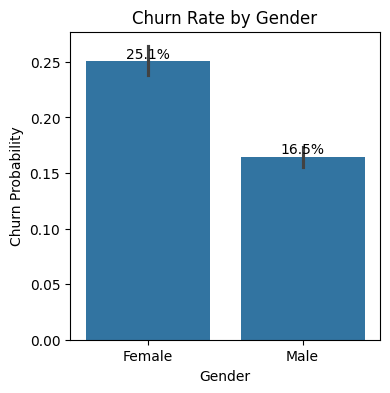

In [10]:
# This chart shows whether churn behavior differs between male and female customers.

plt.figure(figsize=(4,4))
ax = sns.barplot(x='Gender', y='Exited', data=df)
plt.title("Churn Rate by Gender")
plt.ylabel("Churn Probability")
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%",
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()

##Visualize Churn by Geography

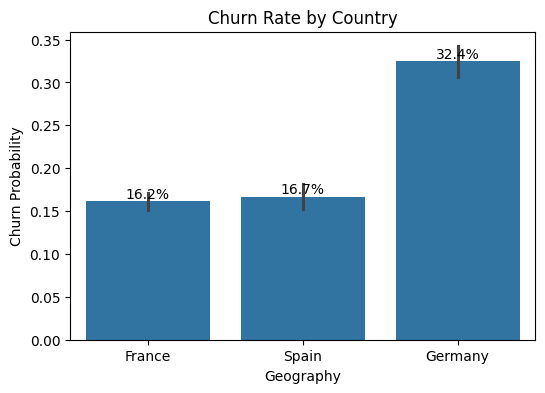

In [11]:
# This analysis helps identify which geographical region has higher customer churn.

plt.figure(figsize=(6,4))
ax = sns.barplot(x='Geography', y='Exited', data=df)
plt.title("Churn Rate by Country")
plt.ylabel("Churn Probability")
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%",
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()

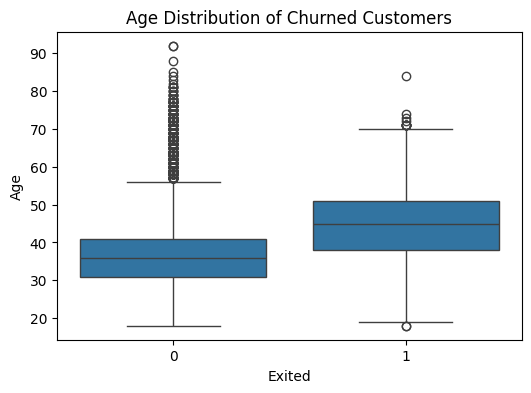

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age Distribution of Churned Customers")
plt.show()

##Encode Categorical Variables

In [14]:
# Categorical variables are converted into numerical values so they can be used
# by machine learning algorithms.

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Geography'] = le.fit_transform(df['Geography'])

##Feature Selection

In [27]:
# Features are separated from the target variable to prepare data for model training.

X = df.drop("Exited", axis=1)
y = df["Exited"]

##Train Test Split

In [16]:
# The dataset is divided into training and testing sets to evaluate the model on
# unseen data.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Train Model

In [17]:
# A Random Forest classifier is trained to predict whether a customer will churn.

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

##Model Prediction

In [18]:
# The trained model predicts churn outcomes for the test dataset.

y_pred = model.predict(X_test)

##Model Accuracy

In [19]:
# Accuracy measures how well the model correctly predicts customer churn.

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8715


##Confusion Matrix

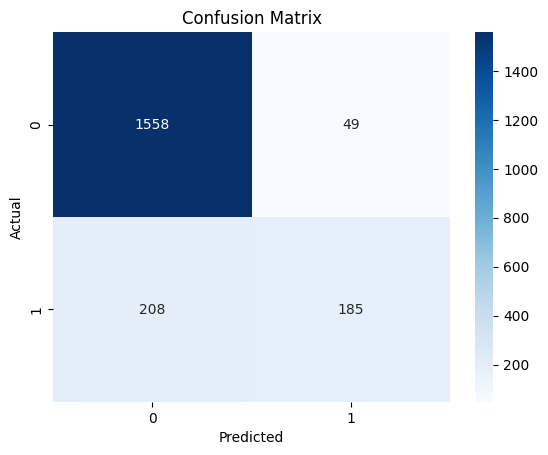

In [20]:
# # The confusion matrix evaluates the model by comparing predicted churn values
# with actual outcomes.

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

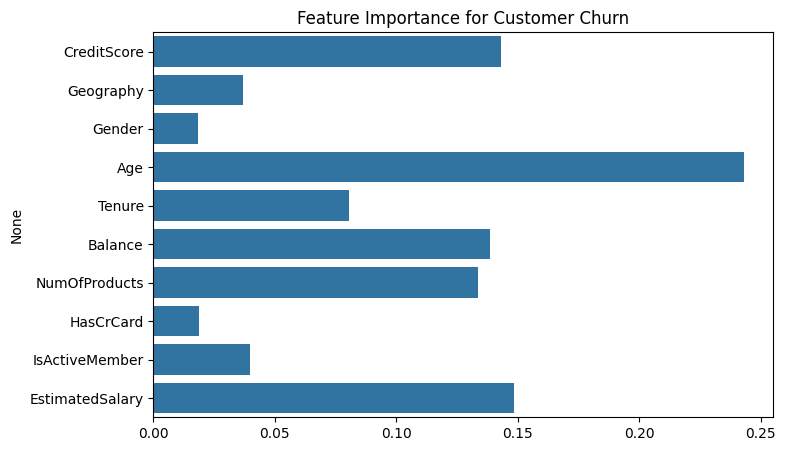

In [26]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

sns.barplot(x=importance, y=features)

plt.title("Feature Importance for Customer Churn")

plt.show()

##Conclusion
This analysis demonstrates how machine learning can identify customers likely to leave a bank. The model highlights key factors influencing churn behavior and helps financial institutions improve customer retention strategies.